# 실습 3 — ML 궤적 후처리: 궤적 평활화와 MPC

> **Day 3**에 진행한다. §2~§4(궤적 평활화)는 acados 없이 실행할 수 있다.
> §5~§8(MPC)에는 **Day 1 실습 0에서 빌드한** MPC solver가 필요하며,
> §0의 `mpc_status()`에서 준비 상태를 확인한다.

실습 2에서는 PLUTO 궤적을 open-loop와 closed-loop로 평가하고 실패 사례를 확인했다. 이번
실습에서는 ML 궤적의 흔들림과 제약 위반 가능성을 분석하고, 두 가지 후처리 방법의
효과를 비교한다.

같은 ML 출력에 두 후처리를 적용하고, 세 궤적을 **매 스텝 같은 조건에서** 채점한다.

| 궤적 | 만드는 법 | 역할과 한계 |
|---|---|---|
| ML | PLUTO 출력 그대로 | 후처리 전 기준 궤적 |
| Smoothed | Savitzky–Golay 필터 | 빠른 변화를 줄이지만 안전 제약은 다루지 않음 |
| Refined | MPC로 궤적 최적화 | 동역학·안전·comfort 제약을 직접 고려 |

산출물은 실습 2와 같다. 매 프레임 점수표가 붙은 **영상**과 nuPlan 공식 **지표**를
확인하며, 점수표에서는 세 궤적을 나란히 비교한다.

| 절 | 내용 | 방식 |
|---|---|---|
| 0 | 준비 | |
| 1 | 후처리란 무엇인가 | 문서 |
| 2 | ML 궤적 특성 관찰 | API |
| 3 | 평활화 필터 비교와 선택 | API |
| 4 | 필터 적용 closed-loop 평가 | config |
| 5 | MPC (1) — Model과 Cost | API |
| 6 | MPC (2) — Constraint와 Solver | API |
| 7 | 한 스텝 풀어 보기 | API |
| 8 | 후처리 전·후 비교 | config |
| 9 | 정리 | |



## 0. 준비

devkit 경로와 환경변수 설정, 필수 파일·GPU·MPC solver 확인.

In [1]:
# 저장소 루트 탐색 · helper 로드 · devkit 환경변수 설정
import sys, pathlib, importlib

NB_DIR = pathlib.Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "run_simulation.py").exists() else NB_DIR.parent
assert (REPO_ROOT / "run_simulation.py").exists(), f"저장소 루트를 찾지 못했습니다: {NB_DIR}"

helper = next(REPO_ROOT.glob("practice/**/_practice3_helper.py"))
sys.path.insert(0, str(helper.parent))

import _practice3_helper
importlib.reload(_practice3_helper)      # 커널에 남은 이전 helper 갱신
from _practice3_helper import *          # noqa: F401,F403

REPO_ROOT = bootstrap()

REPO_ROOT        : /home/user/E2E_Refinement_Practice
NUPLAN_DATA_ROOT : /home/user/E2E_Refinement_Practice/data


In [2]:
# 사전 점검 — checkpoint · GPU · log DB · widget
import importlib.util
import logging
import warnings

# 반복 출력되는 PLUTO attention mask 경고를 숨긴다.
warnings.filterwarnings("ignore", message="Converting mask without torch.bool")
warnings.filterwarnings("ignore", message="Importing from timm.models.layers")
logging.getLogger("nuplan.database.maps_db.gpkg_mapsdb").setLevel(logging.ERROR)

ckpt = REPO_ROOT / PLUTO_CKPT
dbs = list((REPO_ROOT / "data/db/test").glob("*.db"))

print("python  :", sys.executable)
print("ckpt    :", ckpt.name, f"({ckpt.stat().st_size/1e6:.0f} MB)" if ckpt.exists() else "없음")
print("DB      :", len(dbs), "개")
print("widgets :", "OK" if importlib.util.find_spec("ipywidgets") else "없음")

import torch
print("torch   :", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      f"| {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "")

assert ckpt.exists(), f"PLUTO 체크포인트가 없습니다: {ckpt}"
assert len(dbs) > 0, "data/db/test 에 로그 DB 가 없습니다"

python  : /home/user/miniconda3/envs/e2e_refinement/bin/python
ckpt    : pluto_planner.ckpt (51 MB)
DB      : 4 개
widgets : OK
torch   : 2.0.1+cu118 | CUDA: True | NVIDIA T600 Laptop GPU


In [3]:
setup_korean_font()

MPC_READY = mpc_status()
if not MPC_READY:
    cmd = 'cmake() { /usr/bin/cmake "$@"; }; export -f cmake; '
    assert run(cmd + "bash script/install_acados.sh", REPO_ROOT) == 0
    assert run(cmd + "bash script/build_mpc.sh", REPO_ROOT) == 0
    print("설치 완료 — 커널을 재시작한 뒤 노트북을 다시 실행하세요.")

matplotlib 한글 폰트: NanumGothic
acados_template : OK
MPC 솔버(.so)   : OK (0.2 MB)


`MPC_READY=False`이면 설치·빌드 script 자동 실행. 완료 후 커널 재시작 필요.
필터 실습(§2~§4)은 NumPy와 SciPy만 사용하므로 MPC 설치와 무관하다.

## 1. 궤적 후처리

학습 모델이 만든 궤적을 차량에 전달하기 전에 다듬거나 검증하는 단계를 후처리라 한다.
대표적인 방법을 궤적에 개입하는 방식과 다루는 조건에 따라 나누면 다음과 같다.

| | 무엇을 하는가 | 대표 | 특징과 한계 |
|---|---|---|---|
| ① Smoothing | 필터로 궤적을 다듬는다 | Low-pass, Savitzky–Golay, B-spline | 빠르고 단순하지만 안전 제약은 별도 확인 |
| ② Selection | 여러 후보 중 하나를 고른다 | PDM-Closed, Hydra-MDP | 정의한 점수에 따라 성능이 달라짐 |
| ③ Projection | 제약을 고려해 궤적을 수정한다 | PLUTO, GameFormer | 모델과 제약 설계에 따라 만족 수준이 달라짐 |
| ④ Safety Filter | 실행 직전에 안전 조건을 검사한다 | CBF-QP, Predictive Safety Filter | 정의한 안전 조건을 중심으로 개입 |
| ⑤ Fallback | 검증 실패 시 대체 궤적으로 전환한다 | SafetyNet, RAIL | 대체 궤적과 검증 범위가 필요함 |

아래로 갈수록 더 많은 조건을 확인하거나 적극적으로 개입하며, 계산량과 설계 복잡도도 커진다.

**이 실습에서 다루는 것은 ① 과 ③ 이다.**

- **① Smoothing** (§3·§4) — 궤적을 시계열로 보고 빠른 변화를 줄인다. 지도와 주변
  차량을 사용하지 않아 적용은 간단하지만, 충돌이나 차선 이탈은 직접 다루지 않는다.
- **③ Projection** (§5~§8) — ML 궤적을 기준선으로 두고 동역학·충돌·차선 제약을
  직접 고려해 수정한다. 이 실습의 MPC가 여기에 해당한다.

$$\min_{\tau}\; \lVert \tau - \tau_{\mathrm{ML}} \rVert^2_W + \lambda J_{\mathrm{smooth}}(\tau)
\quad \text{s.t.}\quad \text{collision free},\; \text{drivable area},\; \text{comfort}$$

### 왜 후처리가 필요한가

학습 기반 플래너의 출력에 한계가 남는 이유는 네 가지로 정리할 수 있다.

| 원인 | 설명 |
|---|---|
| Open-loop imitation learning | 전문가 궤적 중심으로 학습해, 자기 오차가 누적된 상태를 충분히 경험하지 못함 |
| 프레임 독립 추론 | 직전 계획을 입력받지 않고 매 프레임 새로 생성해 계획이 흔들릴 수 있음 |
| 추론 시 제약 부재 | 충돌 회피와 주행가능영역은 **학습 손실 항으로만** 존재한다 |
| Long-tail 데이터 부족 | 경계에 몰린 차량이나 비정형 장애물 사례가 드물어 학습에 충분히 반영되기 어려움 |

특히 학습 손실은 제약을 평균적으로 잘 지키도록 유도할 뿐, **모든 출력의 제약 만족을
보장하지 않는다.** 실습 2에서 본 closed-loop 실패도 이 관점에서 다시 살펴볼 수 있다.

§2에서 이 특성을 실제 출력으로 확인하고, §3부터 후처리 효과를 차례로 살펴본다.

## 2. ML 궤적 특성 관찰

후처리를 적용하기 전에 원본 궤적의 특성을 확인한다. 실습 2 §2·§3과 같은 방식으로
시나리오와 planner를 준비하고, 여러 스텝의 **ML 궤적을 수집한다.**

In [4]:
# 실습 시나리오 6개 로드 — 첫 번째 시나리오는 §2·§3·§7의 예제
from nuplan.planning.utils.multithreading.worker_sequential import Sequential
from omegaconf import OmegaConf

FILTER_YAML = OmegaConf.load(REPO_ROOT / "config/scenario_filter/practice_scenarios.yaml")

builder = make_builder(REPO_ROOT)
scenarios = builder.get_scenarios(
    make_filter(scenario_tokens=list(FILTER_YAML.scenario_tokens),
                log_names=list(FILTER_YAML.log_names),
                timestamp_threshold_s=FILTER_YAML.timestamp_threshold_s),
    Sequential())

scenario = scenarios[3]
display(scenario_table(scenarios))
print("샘플:", scenario.token, "|", scenario.scenario_type)

,idx,token,scenario_type,log_name,iterations,dt
0,0,56cdd36746c85788,high_magnitude_speed,2021.05.25.14.16.10_veh-35_0,150,0.1
1,1,a112ea9f3d2b5d5b,stationary_in_traffic,2021.06.28.21.23.50_veh-47_0,150,0.1
2,2,bc962c4b185859a6,waiting_for_pedestrian_to_cross,2021.05.25.12.40.06_veh-47_0,150,0.1
3,3,d13124fa683654b4,following_lane_with_lead,2021.06.28.21.23.50_veh-47_0,150,0.1
4,4,f9ac8947d2c55c1b,traversing_pickup_dropoff,2021.05.25.17.38.43_veh-27_0,150,0.1


샘플: d13124fa683654b4 | following_lane_with_lead


### 플래너 구성

실습 2와 같은 네 구성요소를 사용한다. 여기서는 원본 ML 궤적만 관찰하므로 평활화는
끄고, §3에서 같은 출력에 여러 필터를 직접 적용한다.

`render=False`: 이 절에서는 영상 대신 궤적 배열만 사용하며, 렌더링에는 스텝당
약 2초가 더 필요하다. `log_csv=False`: 노트북 커널의 PID가 유지되어 같은 파일에
결과가 중복 저장되는 것을 방지한다.

In [5]:
# PLUTO planner 구성 — smoothing과 MPC 비활성화
from src.feature_builders.pluto_feature_builder import PlutoFeatureBuilder
from src.models.pluto.pluto_model import PlanningModel
from src.planners.model_adapters import PlutoModelAdapter
from src.planners.refinement_planner import RefinementPlanner

feature_builder = PlutoFeatureBuilder(**PLUTO_FEATURE_KWARGS)
model = PlanningModel(feature_builder=feature_builder, **PLUTO_MODEL_KWARGS)
adapter = PlutoModelAdapter(model, planner_ckpt=str(REPO_ROOT / PLUTO_CKPT))

planner = RefinementPlanner(
    model_adapter=adapter,
    scenario=scenario,
    smoothing="none",               # 원본 ML 궤적 관찰
    use_refinement=False,           # MPC는 §5부터 사용
    driving_policy="ml",            # ML 궤적으로 주행, 후처리는 채점만 수행
    render=False,
    log_csv=False,
)

sim = make_sim(scenario)
planner.initialize(sim.initialize())   # checkpoint 로드
print("planner :", planner.name(), "| device:", planner.device)

planner : RefinementPlanner | device: cuda


### ML 궤적 수집

`compute_trajectory`를 호출하면 플래너 안에서 추론이 일어나지만, ML 궤적은 밖으로
나오지 않는다(시뮬레이터에 넘어가는 것은 **선택된** 궤적 하나뿐이다). 어댑터의
출력을 잠깐 가로채 스텝마다 한 벌씩 모아 둔다.

추론 횟수는 늘지 않는다 — 원래 호출을 감싸기만 하고 결과를 그대로 돌려주기 때문이다.

In [6]:
# adapter 출력을 가로채 스텝별 (iteration, ego_state, ML 궤적) 수집
import time

STEPS = 20
captured = []

# 이전 실행의 wrapper 제거 — wrapper 중첩 방지
planner._adapter.__dict__.pop("build_and_forward", None)
_forward = planner._adapter.build_and_forward      # 원본 method

def _record(current_input, initialization):
    ao = _forward(current_input, initialization)
    captured.append((current_input.iteration.index,
                     current_input.history.ego_states[-1],
                     ao.ml_local.cpu().numpy().copy()))
    return ao

planner._adapter.build_and_forward = _record

t0 = time.time()
try:
    for _ in range(STEPS):
        planner_input = sim.get_planner_input()
        sim.propagate(planner.compute_trajectory(planner_input))
finally:
    # 예외 발생 시에도 wrapper 복원
    planner._adapter.__dict__.pop("build_and_forward", None)

print(f"{len(captured)} 스텝 / {time.time() - t0:.0f}s")
print("궤적 모양:", captured[0][2].shape, "— (80, 3) = 8초 × 0.1초, [x, y, yaw] ego-local")

20 스텝 / 25s
궤적 모양: (80, 3) — (80, 3) = 8초 × 0.1초, [x, y, yaw] ego-local


### 관찰 ① — 단일 궤적의 떨림

경로만으로는 잘 보이지 않는 빠른 변화를 곡률과 yaw rate로 확인한다.

- **곡률 κ**는 조향각과 직접 연결된다(δ ≈ atan(κ·L)). 곡률이 급변하면 조향도 불안정해질 수 있다.
- **yaw rate**는 nuPlan comfort metric에 직접 사용된다.

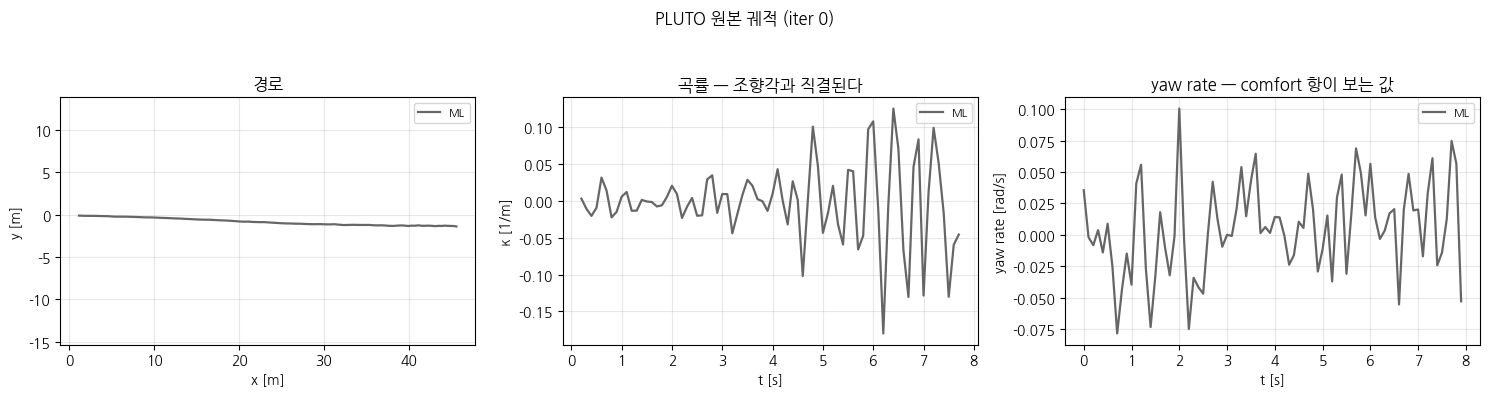

In [7]:
%matplotlib inline

# 단일 ML 궤적 — path · curvature · yaw rate
iter0, ego0, ml0 = captured[0]
fig, axes = plot_trajectory_signals({"ML": ml0}, dt=0.1,
                                    title=f"PLUTO 원본 궤적 (iter {iter0})")

경로만 보면 매끄럽지만 곡률과 yaw rate에는 빠른 진동이 보인다. 이런 변화는 추종
과정에서 조향과 yaw acceleration을 흔들어 comfort를 낮출 수 있다.

### 관찰 ② — 프레임 간 계획 변화

플래너는 0.1초마다 궤적을 새로 만든다. 전체 경로는 비슷해 보여도, 같은 미래 시점에
대한 계획 위치는 달라질 수 있다.

연속된 다섯 계획을 겹쳐 보고, 새 계획이 직전 계획을 얼마나 수정했는지 확인한다.

NameError: name '____' is not defined

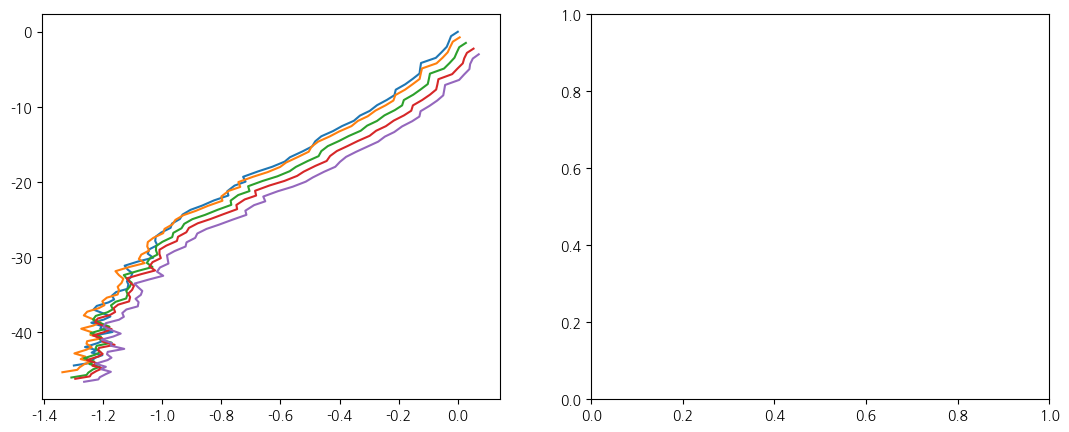

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sel = captured[:5]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
plans = [(it, planner._to_global_trajectory(ml, ego)) for it, ego, ml in sel]
origin = plans[0][1][0, :2]  # 큰 지도 좌표 대신 첫 계획 시작점을 공통 원점으로 사용

# 전체 경로
for it, g in plans:
    ax[0].plot(*(g[:, :2] - origin).T, label=f"iter {it}")

# 공통 예측 시점의 위치 차이
for (a, ga), (b, gb) in zip(plans, plans[1:]):
    shift = b - a
    ga, gb = ga[shift:], gb[:-shift]  # TODO ① 공통 예측 시점 정렬
    d = np.linalg.norm(ga[:, :2] - gb[:, :2], axis=1)  # TODO ② 두 계획의 위치 차이
    t = (np.arange(len(d)) + shift + 1) * .1
    ax[1].plot(t, d, label=f"{a}→{b}")

ax[0].set(title="연속 5스텝의 계획", xlabel="Δx [m]", ylabel="Δy [m]")
ax[1].set(title="공통 예측 시점의 위치 차이",
          xlabel="첫 계획 기준 미래 시간 [s]", ylabel="위치 차이 [m]")

for a in ax:
    a.grid(alpha=.3)
    a.legend(fontsize=8)

fig.tight_layout()

In [9]:
# 인접 계획의 위치 차이 요약
import pandas as pd

rows = []
for (it_a, ga), (it_b, gb) in zip(plans, plans[1:]):
    shift = it_b - it_a
    ga, gb = ga[shift:], gb[:-shift]
    d = np.linalg.norm(ga[:, :2] - gb[:, :2], axis=1)
    rows.append({"iter": f"{it_a}→{it_b}", "평균 [m]": d.mean(),
                 "최대 [m]": d.max(),
                 "최대 지점 [s]": (np.argmax(d) + shift + 1) * .1})
display(pd.DataFrame(rows).round(3))

,iter,평균 [m],최대 [m],최대 지점 [s]
0,0→1,0.196,0.577,8.0
1,1→2,0.119,0.378,8.0
2,2→3,0.099,0.257,7.3
3,3→4,0.139,0.257,3.1


**확인 사항**

- 가까운 미래는 비슷하지만 먼 미래로 갈수록 수정량이 커진다. 먼 미래는 불확실성이
  크므로 어느 정도의 차이는 자연스럽다.
- 이 값에는 경로 변경과 속도 계획 수정이 함께 들어 있다. 따라서 차이가 있다는 사실만으로
  문제라고 단정하지 않고, 가까운 미래에서 크거나 반복적으로 급변하는지를 본다.
- 단일 궤적을 다듬는 §3의 필터는 프레임 사이의 변화를 직접 제어하지 않는다. 이전
  해를 초기값으로 쓰는 warm start는 계획 변화를 줄이는 데 도움을 줄 수 있다.

관찰한 특성마다 대응 방법이 다르다.

| 관찰한 특성 | 이어서 살펴볼 방법 |
|---|---|
| 한 궤적 안의 떨림 | 평활화 (§3) |
| 프레임 간 계획 변화 | 이전 해를 초기값으로 사용해 완화 가능 (§7) |
| 차선 이탈 · 충돌 | 제약 (§6) |

## 3. Smoothing filter 비교와 선택

§2에서 확인한 궤적 내부의 떨림을 평활화 필터로 줄인다. Butterworth는 차단주파수로,
Savitzky–Golay는 창 길이와 다항식 차수로 평활 강도를 조절한다. 같은 ML 궤적에
여러 설정을 적용해 부드러움과 원본 보존 정도를 비교한다.

구현은 [`src/planners/postprocess/lowpass.py`](../src/planners/postprocess/lowpass.py)
에 있다. 두 가지 선택이 들어가 있다.

**① 위치가 아니라 증분(diff)을 필터링한다.**
위치 x는 시간에 따라 거의 직선으로 증가하는 ramp 신호다. ramp를 causal filter에 넣으면
정상상태 지연이 남아 궤적 전체가 뒤로 밀리고, 결과적으로 차가 느려진다. 증분은 거의
상수(≈ v·dt)라 이 문제가 없다. 필터의 DC gain이 1이므로 증분의 평균이 보존되고,
따라서 **총 이동거리가 거의 보존된다.** 현재 자차 원점을 기준으로 적분하므로 궤적이
원점에서 통째로 밀리는 현상도 막는다.

**② yaw를 x, y와 독립적으로 필터링한다.**
부드러워진 경로에서 yaw = atan2(dy, dx)로 다시 만들 수도 있지만, 저속에서 dx, dy가
0에 가까워지면 발산한다. 시뮬레이터와 채점기 모두 궤적을 LQR + 자전거 모델로 추종하므로
약간의 불일치는 추종 단계에서 흡수된다.

### Smoothing filter 3종 비교

| 필터 | 방식 | 위상 지연 | 특징 |
|---|---|---|---|
| `zerophase` | filtfilt — 정·역방향 2회 통과 | **없음** | 계획 궤적은 전 구간이 이미 손에 있어 가능하다 |
| `causal` | lfilter — 정방향 1회 | 있음 | 과거와 현재 값만 사용하므로 반응 지연이 생김 |
| `savgol` | 국소 다항식 적합 | 거의 없음 | 차단주파수 대신 창 길이로 평활 강도를 정함 |

필터가 궤적을 얼마나 부드럽게 만들고, 원래 경로를 얼마나 바꾸었는지 숫자로 확인한다.

- **|κ| peak (내부)**: 수치미분 오차가 큰 양 끝 두 점을 제외한 곡률 peak 값이다.
- **yaw rate std**: yaw rate의 변동 정도다. comfort 경향을 보는 보조 지표이며,
  공식 comfort 점수 자체는 아니다.
- **경로 길이**: 궤적이 이동하는 총거리다. 필터로 차량의 진행 거리가 달라졌는지 확인한다.
- **첫 waypoint 이동**: 필터 전후 첫 예측점의 차이다. 작을수록 단기 계획을 잘 보존한다.
- **종점 이동**: 필터 전후의 종점 차이다. 작을수록 원래 목적 위치를 잘 보존한다.

In [ ]:
# 동일 ML 궤적에 smoothing filter 3종 적용
from src.planners.postprocess import LowPassTrajectoryFilter, curvature, heading_rate

variants = {"ML": ml0}
for mode in ("zerophase", "causal", "savgol"):
    f = LowPassTrajectoryFilter(dt=0.1, cutoff_hz=1.0, mode=mode)
    variants[mode] = f(ml0, origin=(0.0, 0.0, 0.0))   # origin = 현재 자차 위치

fig, axes = plot_trajectory_signals(variants, dt=0.1, title="Smoothing filter 3종 비교")

In [ ]:
# Smoothness와 원본 궤적 보존 정도 비교
rows = []
for name, tr in variants.items():
    path_len = np.linalg.norm(np.diff(tr[:, :2], axis=0), axis=1).sum()
    rows.append({
        "궤적": name,
        "|κ| peak (내부) [1/m]": np.abs(curvature(tr)[2:-2]).max(),
        "yaw rate std [rad/s]": heading_rate(tr, 0.1).std(),
        "경로 길이 [m]": path_len,
        "첫 waypoint 이동 [m]": float(np.linalg.norm(tr[0, :2] - ml0[0, :2])),
        "종점 이동 [m]": float(np.linalg.norm(tr[-1, :2] - ml0[-1, :2])),
    })
display(pd.DataFrame(rows).round(4))

세 필터 모두 곡률의 빠른 변화를 줄이지만 결과는 다르다. `causal`은 위상 지연 때문에
종점 이동이 크고, `zerophase`와 `savgol`은 원본 형상을 더 잘 보존한다. 이제 각
필터의 평활 강도를 바꿔 적절한 설정을 찾는다.

### Butterworth 차단주파수 비교

In [ ]:
# Zero-phase Butterworth cutoff frequency sweep
sweep = {"ML": ml0}
for hz in (2.0, 1.0, 0.5, 0.3):
    sweep[f"{hz} Hz"] = LowPassTrajectoryFilter(dt=0.1, cutoff_hz=hz)(ml0, origin=(0, 0, 0))

fig, axes = plot_trajectory_signals(sweep, dt=0.1, title="Cutoff frequency sweep (zero-phase)")
plt.show()

display(pd.DataFrame([
    {"차단주파수": name,
     "|κ| peak (내부) [1/m]": np.abs(curvature(tr)[2:-2]).max(),
     "yaw rate std [rad/s]": heading_rate(tr, 0.1).std(),
     "ML 대비 최대 편차 [m]": float(np.abs(tr[:, :2] - ml0[:, :2]).max())}
    for name, tr in sweep.items()
]).round(4))

차단주파수를 낮추면 곡률 peak는 줄지만 yaw rate 변동과 원본 대비 편차는 오히려
커진다. 더 강한 평활화가 항상 더 좋은 것은 아니다. `cutoff_hz`는 Butterworth
계열에만 적용되며, `savgol`은 창 길이로 평활 강도를 정한다.

### Savitzky–Golay parameter 비교

In [ ]:
# 긴 window: 넓은 구간 평활화 · 높은 order: 세부 형상 보존
sg = {"ML": ml0}
for w, p in ((7, 3), (11, 3), (15, 3), (11, 2), (15, 2)):
    f = LowPassTrajectoryFilter(mode="savgol", savgol_window=w, savgol_polyorder=p)
    sg[f"w={w}, p={p}"] = f(ml0, origin=(0, 0, 0))

fig, axes = plot_trajectory_signals(sg, dt=0.1, title="Savitzky–Golay parameter sweep")
plt.show()
display(pd.DataFrame([
    {"설정": name, "|κ| peak (내부) [1/m]": np.abs(curvature(tr)[2:-2]).max(),
     "yaw rate std [rad/s]": heading_rate(tr, .1).std(),
     "종점 이동 [m]": np.linalg.norm(tr[-1, :2] - ml0[-1, :2])}
    for name, tr in sg.items()
]).round(4))

SAVGOL_WINDOW, SAVGOL_POLYORDER = ____, ____  # TODO ③ 위 결과표를 보고 선택
print("선택: savgol", SAVGOL_WINDOW, SAVGOL_POLYORDER)

`p=3`에서 창 길이를 `w=11`에서 `w=15`로 늘리면 곡률 peak는 줄고, yaw rate std도 낮아진다.
종점 이동 역시 소폭 감소해 평활화와 원본 경로 보존이 함께 개선된다. `p=2`는 곡률 peak를 더 크게 줄이지만, `w=11`과
`w=15` 모두 `p=3`보다 yaw rate std가 크고 종점 이동도 
커진다. 따라서 yaw rate 변동을 가장 낮은 수준으로 줄이면서 경로 변형을
억제하는 절충안으로 **창 길이 15, 다항식 차수 3**을 선택한다.

### 평활화의 한계 — 잡음과 실제 기동을 구분하지 못한다

평활화 필터는 빠른 변화가 떨림인지 필요한 기동인지 구분하지 못한다. 계단 신호 대신
물리적으로 연속이지만 1초 만에 2 m 이동하는 **급회피 profile**을 만들고, ML 궤적에서
나타날 수 있는 작은 고주파 흔들림을 추가한다. 필요한 기동을 얼마나 보존하면서
흔들림을 줄이는지가 비교 기준이다.

In [ ]:
# 급회피 기동 — 3~4초, 2 m 이동 + 작은 ML 흔들림
T, dt, v = 80, 0.1, 10.0
t = np.arange(1, T + 1) * dt
u = np.clip((t - 3.0) / 1.0, 0, 1)
y_ref = 2.0 * (10*u**3 - 15*u**4 + 6*u**5)  # minimum-jerk profile
y_ml = y_ref + 0.03 * np.sin(2*np.pi*3*t)     # 3 Hz, 3 cm 흔들림
ml_lane = np.c_[v*t, y_ml, np.arctan2(np.gradient(y_ml, dt), v)]

filters = {
    "savgol w15 p3": LowPassTrajectoryFilter(
        dt=dt, mode="savgol", savgol_window=15, savgol_polyorder=3),
    "zerophase 1.0 Hz": LowPassTrajectoryFilter(dt=dt, cutoff_hz=1.0, mode="zerophase"),
    "causal 1.0 Hz": LowPassTrajectoryFilter(dt=dt, cutoff_hz=1.0, mode="causal"),
    "zerophase 0.3 Hz": LowPassTrajectoryFilter(dt=dt, cutoff_hz=0.3, mode="zerophase"),
}
signals = {"ML (흔들림 포함)": ml_lane,
           **{name: f(ml_lane, origin=(0, 0, 0)) for name, f in filters.items()}}

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(t, y_ref, "k--", lw=2, label="기준 급회피")
for name, tr in signals.items():
    ax[0].plot(t, tr[:, 1], lw=1.5, label=name)
    ax[1].plot(t, tr[:, 1] - y_ref, lw=1.5, label=name)
ax[0].set(title="급회피 형상", xlabel="t [s]", ylabel="y [m]")
ax[1].set(title="기준 기동과의 횡방향 오차", xlabel="t [s]", ylabel="error [m]")
for a in ax: a.grid(alpha=.3)
ax[0].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

display(pd.DataFrame([
    {"설정": name,
     "기준 경로 RMSE [m]": np.sqrt(np.mean((tr[:, 1] - y_ref)**2)),
     "yaw accel peak [rad/s²]": np.abs(np.gradient(heading_rate(tr, dt), dt)[2:-2]).max()}
    for name, tr in signals.items()
]).round(4))

**확인 사항**

- ML 원본의 작은 흔들림은 yaw acceleration peak를 크게 만든다.
- `savgol w15 p3`은 yaw acceleration을 낮추지만, 원본보다 기준 경로 RMSE가 커진다.
  즉, 떨림뿐 아니라 필요한 급회피 형상도 일부 바꾼다.
- `causal`은 반응 지연으로 경로 오차가 커진다. `zerophase 0.3 Hz`는 yaw acceleration
  peak는 가장 작지만 기동을 넓게 퍼뜨려 경로 RMSE가 크게 증가한다.
- 평활화는 궤적의 빠른 변화를 줄이지만 차선과 주변 차량을 확인하지 않는다. 따라서
  차선 이탈과 충돌 가능성은 별도로 다뤄야 하며, §5부터 MPC로 이를 살펴본다.

이후에는 전체 균형이 가장 좋은 Savitzky–Golay 설정(`window=15`, `polyorder=3`)을 사용한다.
다음 절에서 이 설정이 원본 ML 궤적의 comfort를 개선하는지 closed-loop로 확인한다.

## 4. 필터 효과 평가: 같은 상태 비교와 closed-loop 주행

§3에서 선택한 Savitzky–Golay 설정(`window=15`, `polyorder=3`)을 시나리오 6개에 적용한다.
`run_simulation.py`를 사용해 공식 closed-loop metric을 계산한다.

평가를 두 번 실행한다. 두 런이 답하는 질문은 서로 다르다.

| 런 | `driving_policy` | 답하는 질문 |
|---|---|---|
| A | `ml` | 같은 상태에서 평활 궤적의 후보 점수가 나아지는가 |
| B | `smooth` | 평활 궤적을 실제로 따라가면 closed-loop 점수가 나아지는가 |

런 A는 ML로 주행하면서 매 스텝 ML과 Smoothed 후보를 같은 조건에서 채점한다. 필터
자체의 영향을 약 900개 스텝에서 비교할 수 있다. 런 B는 Smoothed 궤적으로 실제
주행하므로 공식 최종 점수로 closed-loop 효과를 확인한다.

> 시나리오 6개를 ray 워커 6개로 동시에 실행한다. 첫 파이썬 프로세스가 시작하는 데
> 약 2분이 걸릴 수 있으니(공유 저장소 조회) 출력이 멈춘 것처럼 보여도 기다린다.
> 런당 약 13분 소요.

In [ ]:
# [런 A] ML 주행 · Savitzky–Golay 후보 동시 채점
if "SAVGOL_WINDOW" not in globals() or "SAVGOL_POLYORDER" not in globals():
    SAVGOL_WINDOW = 15
    SAVGOL_POLYORDER = 3
    print("SAVGOL 설정이 없어 기본값(window=15, polyorder=3)을 사용합니다.")

RUN_ML = run_sim(uid="practice3/ml_savgol_w15", driving_policy="ml",
                 smoothing="savgol", smoothing_savgol_window=SAVGOL_WINDOW,
                 smoothing_savgol_polyorder=SAVGOL_POLYORDER,
                 use_refinement=False, video_dir="videos")
print("결과:", RUN_ML)

### 같은 상태에서 후보 궤적 비교

플래너가 매 스텝 저장한 CSV를 읽는다. 한 행에 `ml_`와 `sm_` 접두사로 두 궤적의 지표가
나란히 들어 있으며, 둘은 같은 ego 상태 · 같은 주변 차량 · 같은 시간 창으로 채점되었다.

In [ ]:
# 후보별 평균 점수 · ML 대비 개선/악화 스텝 수
display(step_comparison(RUN_ML))

In [ ]:
# Metric별 score 변화
display(step_metric_deltas(RUN_ML, candidate="sm"))

`delta`가 양수면 개선, 음수면 악화다. 먼저 목표 metric인 `ego_is_comfortable`을 보고,
안전 관련 metric이 함께 나빠지지 않았는지 확인한다.

곱셈 항(`no_ego_at_fault_collisions`, `drivable_area_compliance`,
`driving_direction_compliance`, `ego_is_making_progress`)의 `delta`를 특히 본다.
필터는 곱셈 항을 지키도록 설계된 방법이 아니다. 작은 comfort 개선보다 곱셈 항의
악화가 최종 점수에 더 큰 영향을 줄 수 있다.

아래 그림은 전체 점수를 다시 그리지 않고, **comfort 판정이 달라진 시점만** 표시한다.
위쪽은 Smoothed가 개선한 스텝, 아래쪽은 악화한 스텝이다.

In [ ]:
# 시나리오별 comfort 판정 변화 시점
steps = load_step_csv(RUN_ML).copy()
for c in ("ml_ego_is_comfortable", "sm_ego_is_comfortable"):
    steps[c] = pd.to_numeric(steps[c], errors="coerce")
steps["comfort Δ"] = steps["sm_ego_is_comfortable"] - steps["ml_ego_is_comfortable"]

scenario_names = {s.token: s.scenario_type for s in scenarios}
tokens = [s.token for s in scenarios if s.token in set(steps["token"])]
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, token in zip(axes.flat, tokens):
    g = steps[steps["token"] == token].sort_values("iteration")
    up = g[g["comfort Δ"] > 0]
    down = g[g["comfort Δ"] < 0]
    ax.vlines(up["iteration"] * .1, 0, up["comfort Δ"], color="#2E8B57", alpha=.5)
    ax.scatter(up["iteration"] * .1, up["comfort Δ"], marker="^",
               color="#2E8B57", label="comfort 개선")
    ax.vlines(down["iteration"] * .1, 0, down["comfort Δ"], color="#C62828", alpha=.5)
    ax.scatter(down["iteration"] * .1, down["comfort Δ"], marker="v",
               color="#C62828", label="comfort 악화")
    ax.axhline(0, color="black", lw=.7)
    ax.set_title(f"{scenario_names[token]} ({token[:8]})\n개선 {len(up)} · 악화 {len(down)}", fontsize=10)
    ax.grid(axis="x", alpha=.3); ax.set_ylim(-1.15, 1.15)
    if len(up) + len(down) == 0:
        ax.text(.5, .55, "변화 없음", transform=ax.transAxes, ha="center", color="#777777")
for ax in axes[-1]: ax.set_xlabel("주행 시간 [s]")
for ax in axes[:, 0]:
    ax.set_yticks([-1, 0, 1], ["악화", "동일", "개선"])
axes[0, 0].legend(fontsize=8)
fig.suptitle("스텝별 comfort 판정 변화 (Smoothed - ML)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, .96])

In [ ]:
# [런 B] Savitzky–Golay 궤적으로 closed-loop 주행
if "SAVGOL_WINDOW" not in globals() or "SAVGOL_POLYORDER" not in globals():
    SAVGOL_WINDOW = 15
    SAVGOL_POLYORDER = 3
    print("SAVGOL 설정이 없어 기본값(window=15, polyorder=3)을 사용합니다.")

RUN_SMOOTH = run_sim(uid="practice3/smooth_savgol_w15", driving_policy="smooth",
                     smoothing="savgol", smoothing_savgol_window=SAVGOL_WINDOW,
                     smoothing_savgol_polyorder=SAVGOL_POLYORDER,
                     use_refinement=False, video_dir="videos")
print("결과:", RUN_SMOOTH)

In [ ]:
# 공식 최종 점수 · metric 평균
display(compare_runs({"ML 주행": RUN_ML, "Smoothed 주행": RUN_SMOOTH}))

In [ ]:
# 시나리오별 점수 비교
display(compare_scenarios({"ML 주행": RUN_ML, "Smoothed 주행": RUN_SMOOTH}))

In [ ]:
# 영상 비교 — ML: 자홍 실선 · Smoothed: 초록 점선
display(scenario_video_browser(RUN_SMOOTH, tag="p3_smooth", columns=CLOSED_BREAKDOWN))

**결과 해석**

- 같은 상태에서 비교한 런 A에서는 comfort 통과율이 약 **4.9%p** 올랐고, 전체 스텝
  평균 점수도 약 **0.006** 상승했다. Savitzky–Golay가 단일 궤적의 떨림을 줄인 효과다.
- 실제로 Smoothed 궤적을 따라간 런 B에서는 최종 점수가 `0.6031 → 0.6073`으로 소폭
  올랐지만, 공식 comfort는 `0.6667 → 0.6667`로 같았다.
- 즉, **한 스텝의 후보 궤적을 부드럽게 만드는 것과 closed-loop comfort를 높이는 것은
  같은 문제가 아니다.** 필터는 계산 부담이 작지만 안전과 comfort 제약을 직접 다루지 않는다.

평활화만으로 얻을 수 있는 효과와 한계를 확인했다. §5부터는 안전과 comfort 조건을
최적화 문제에 직접 포함하는 MPC를 살펴본다.

## 5. MPC (1) — Model과 Cost

MPC는 ML 궤적을 **reference**로 두고, constraint를 고려하면서 reference에 가까운
궤적을 찾는다. §1에서 본 ③ Projection에 해당한다.

$$\min_{x, u}\; \sum_{k=0}^{N-1} \ell(x_k, u_k, p_k) \quad
\text{s.t.}\quad \dot{x} = f(x, u),\; h(x, u, p) \ge 0$$

이 절에서는 vehicle model $f$와 cost $\ell$을 실제 solver 객체에서 확인한다. 코드는
[`Trajectory_refinement/refinementMPC/refinement_mpc_solver.py`](../Trajectory_refinement/refinementMPC/refinement_mpc_solver.py)
에 있으며 parameter는
[`refinement_mpc_params.yaml`](../Trajectory_refinement/refinementMPC/refinement_mpc_params.yaml)
에 있다.

In [ ]:
# MPC solver 로드 — YAML의 b_acados_generation=false이므로 기존 .so 사용
import os, sys, pathlib, importlib

# 앞부분 셀을 건너뛰고 바로 실행해도 되도록 환경을 다시 복구한다.
NB_DIR = pathlib.Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "run_simulation.py").exists() else NB_DIR.parent
helper = next(REPO_ROOT.glob("practice/**/_practice3_helper.py"))
sys.path.insert(0, str(helper.parent))
import _practice3_helper
importlib.reload(_practice3_helper)
from _practice3_helper import bootstrap
REPO_ROOT = bootstrap(verbose=False)

ACADOS_LIB = REPO_ROOT / "Trajectory_refinement/acados/lib"
assert ACADOS_LIB.exists(), f"acados lib 디렉터리가 없습니다: {ACADOS_LIB}"

# LD_LIBRARY_PATH 는 이미 떠 있는 커널의 dlopen 검색 경로를 바꾸지 못하므로,
# 의존 공유 라이브러리를 절대 경로로 먼저 preload 한다.
import ctypes
for so_name in ("libblasfeo.so", "libblasfeo.so.0", "libblasfeo.so.0.1.4.2",
                "libhpipm.so", "libqpOASES_e.so", "libacados.so"):
    so_path = ACADOS_LIB / so_name
    if so_path.exists():
        ctypes.CDLL(str(so_path), mode=ctypes.RTLD_GLOBAL)

print("ACADOS_SOURCE_DIR:", os.environ.get("ACADOS_SOURCE_DIR", "없음"))
print("LD_LIBRARY_PATH   :", os.environ.get("LD_LIBRARY_PATH", "없음"))

from Trajectory_refinement.refinementMPC.refinement_mpc_solver import (
    MPCConstants, RefinementMPC,
 )

mpc = RefinementMPC()
print("초기화:", mpc.initialized)
print(f"예측 구간 T = {mpc.T} 스텝 × dt = {mpc.dt}s = {mpc.horizon}s  (ML 궤적과 같은 길이)")

### Vehicle model — Kinematic bicycle model

6개 state와 2개 control input을 사용한다.

In [ ]:
# State · control input · dynamics
state_names = ["x", "y", "yaw", "v", "ax", "delta"]
input_names = ["jerk", "ddelta"]

print("상태 x :", mpc.model.x)
print("입력 u :", mpc.model.u)
print()
for name, expr in zip(state_names, [mpc.model.f_expl_expr[i] for i in range(6)]):
    print(f"  d{name}/dt = {expr}")
print(f"\nwheel_base L = {mpc.wheel_base} m")

| | 기호 | 뜻 |
|---|---|---|
| 상태 | x, y, yaw | 뒷차축 기준 위치와 방위 |
| | v | 종방향 속도 |
| | ax | 종방향 가속도 |
| | delta | 조향각 |
| 입력 | jerk | 가속도의 변화율 |
| | ddelta | 조향각의 변화율 |

가속도와 조향각을 state로 두고, 그 변화율인 jerk와 `ddelta`를 control input으로
사용한다. 이를 통해 solver가 comfort와 관련된 값도 cost와 constraint에 포함할 수 있다.

$$a_y = \frac{v^2 \tan\delta}{L}, \qquad
\dot\psi = \frac{v \tan\delta}{L}, \qquad
\ddot\psi \approx \frac{a_x \delta + v\,\dot\delta}{L}$$

마지막 식은 solver에서 사용하는 small-angle approximation이다. $\dot\psi$를 정확히
미분한 식과는 차이가 있으므로, nuPlan metric을 그대로 재현한다기보다 최적화에 사용할
근사값으로 이해한다.

### Parameter — MPC에 전달되는 환경 정보

MPC는 지도와 주변 객체를 직접 읽지 않는다. 필요한 정보는 매 스텝 parameter vector
`p`로 변환해 전달한다.


In [ ]:
# Parameter vector layout
import pandas as pd

K = MPCConstants.ParameterIndices
layout = [
    ("기준선 (x, y, yaw, v)", K.REF_TRAJECTORY_START, K.REF_TRAJECTORY_END,
     "ML 궤적에 속도를 붙인 것"),
    ("주변 차량 10대 × 3점 × (x, y)", K.AGENT_DATA_START, K.AGENT_DATA_END,
     "로그상 미래에서 가까운 순으로 추린다"),
    ("보행자 5명 × (x, y)", K.PEDESTRIAN_START, K.PEDESTRIAN_END, ""),
    ("차량 폭 10개", K.AGENT_WIDTHS_START, K.AGENT_WIDTHS_END, "충돌 반경 계산용"),
    ("차선 경계 상한 4개", K.BOUNDARY_LIMITS_START, K.BOUNDARY_LIMITS_END,
     "좌/우 × 전축/후축의 횡방향 한계"),
]
display(pd.DataFrame(
    [{"항목": n, "인덱스": f"{a}–{b}", "개수": b - a + 1, "비고": c}
     for n, a, b, c in layout]
))
print("p 전체 길이:", mpc.model.p.rows())

차선 경계는 선 전체가 아니라 현재 위치에서 허용되는 횡방향 범위 4개로 전달된다.
MPC는 이 숫자를 이용해 전·후축의 좌우 경계를 제한한다.
그 변환은 [`src/planners/utils/mpc_interface.py`](../src/planners/utils/mpc_interface.py)
가 담당한다.

### Cost — 포화 kernel을 사용하는 이유

Reference tracking에는 보통 $\lVert e \rVert^2$을 사용하지만, 이 solver는 포화되는
kernel cost를 사용한다.

$$\mathrm{kernel}(e) = \frac{\tanh(a\,e^2 + b) + 1}{2} \in [0, 1]$$

In [ ]:
# Solver에 설정된 stage/terminal cost
print("stage cost   :", mpc.ocp.model.cost_expr_ext_cost)
print()
print("terminal cost:", mpc.ocp.model.cost_expr_ext_cost_e)
print()
print(f"use_kernel_cost = {mpc.use_kernel_cost}  (0이면 stage cost 비활성화)")

In [ ]:
# Kernel shape · 비용이 0.5가 되는 기준 오차 sqrt(-shift/scale)
def kernel(e, scale, shift):
    return (np.tanh(scale * e**2 + shift) + 1.0) / 2.0

specs = [
    ("x 오차 [m]",      mpc.kernel_scale_x,      mpc.kernel_shift_x,      4.0, mpc.Q_x),
    ("y 오차 [m]",      mpc.kernel_scale_y,      mpc.kernel_shift_y,      4.0, mpc.Q_y),
    ("yaw 오차 [rad]",  mpc.kernel_scale_yaw,    mpc.kernel_shift_yaw,    0.6, mpc.Q_yaw),
    ("jerk [m/s³]",     mpc.kernel_scale_jerk,   mpc.kernel_shift_jerk,   4.0, mpc.R_jerk),
    ("ddelta [rad/s]",  mpc.kernel_scale_ddelta, mpc.kernel_shift_ddelta, 1.0, mpc.R_ddelta),
]

fig, axes = plt.subplots(1, len(specs), figsize=(4 * len(specs), 3.4))
rows = []
for ax, (label, scale, shift, emax, weight) in zip(axes, specs):
    e = np.linspace(-emax, emax, 400)
    ax.plot(e, kernel(e, scale, shift), lw=2, color="#1F5FB4")
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    sens = np.sqrt(-shift / scale) if scale > 0 else np.nan
    if np.isfinite(sens):
        ax.axvline(sens, color="#C0392B", ls="--", lw=1)
        ax.axvline(-sens, color="#C0392B", ls="--", lw=1)
    ax.set_title(f"{label}\n가중치 {weight}", fontsize=10)
    ax.set_xlabel("오차"); ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
    rows.append({"항": label, "scale a": scale, "shift b": shift,
                 "민감점 √(-b/a)": sens, "가중치": weight})
axes[0].set_ylabel("kernel")
fig.tight_layout()
display(pd.DataFrame(rows).round(4))

In [ ]:
# Quadratic cost와 kernel cost 비교
e = np.linspace(-8, 8, 600)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e, (e / mpc.N_x) ** 2, lw=2, label="이차식  (e/N_x)²", color="#B8860B")
ax.plot(e, kernel(e, mpc.kernel_scale_x, mpc.kernel_shift_x), lw=2,
        label="커널  (tanh(a e²+b)+1)/2", color="#1F5FB4")
ax.axvline(np.sqrt(-mpc.kernel_shift_x / mpc.kernel_scale_x), color="#C0392B", ls="--", lw=1)
ax.set_xlabel("x 오차 [m]"); ax.set_ylabel("비용"); ax.set_ylim(0, 3)
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Quadratic cost와 saturated kernel cost")
fig.tight_layout()

**Kernel cost의 핵심은 saturation이다.**

- Quadratic cost는 오차가 커질수록 비용이 계속 증가한다.
- Kernel cost는 큰 오차에서 1로 포화되어, 큰 tracking error 하나가 비용을 과도하게 키우는 것을 막는다.
- x, y 약 2 m와 yaw 약 0.3 rad(17°)에서 kernel 값이 0.5가 된다.

`Q_yaw`는 위치뿐 아니라 진행 방향도 reference에 가깝게 만드는 항이다. Overshoot 감소
여부는 다른 cost와 constraint의 영향도 받으므로 실행 결과로 확인해야 한다.


### 빈칸 실습 1 — Model과 Cost 구현

이제 확인한 model과 cost를 직접 구현한다.
[`refinement_mpc_solver.py`](../Trajectory_refinement/refinementMPC/refinement_mpc_solver.py)
에는 아래 네 곳이 `# TODO` 로 비어 있다.

| 빈칸 | 위치 | 채울 것 |
|---|---|---|
| 1-① | `CreateModel` — `f_expl` | 운동학 자전거 모델의 미분식 |
| 1-② | `CreateModel` — comfort 보조식 | `ay`, `yawrate`, `yaw_accel` |
| 1-③ | `SetupCostExpressions` — 커널 | `(tanh(a·e² + b) + 1) / 2` |
| 1-④ | `SetupCostExpressions` — cost 조립 | stage / terminal 비용 |

빈칸 상태에서도 build는 완료될 수 있지만 model과 cost가 의도대로 동작하지 않는다.
자가 점검으로 각 식을 확인한 뒤 §7에서 실제 trajectory를 비교한다.

#### 수정 내용 반영

```bash
bash script/build_mpc.sh      # code generation + compile
```

완료 후 kernel을 재시작하고 §0부터 다시 실행한다.

> 재빌드하지 않으면 Python source만 바뀌고 실제 solve에는 기존 `.so`가 사용된다.
> 위의 수정 시각 검사에서 반영 여부를 확인할 수 있다.

필요하면 같은 디렉터리의 `refinement_mpc_solver_answer.py`와 비교한다.

```bash
cd Trajectory_refinement/refinementMPC
diff -u refinement_mpc_solver.py refinement_mpc_solver_answer.py   # 정답 확인
cp refinement_mpc_solver_answer.py refinement_mpc_solver.py        # 되돌리기
```

In [ ]:
# 자가 점검 1 — 구현한 식의 수치 검증
import numpy as np, casadi as ca

L  = mpc.wheel_base
xs = np.array([0.0, 0.0, 0.30, 10.0, 1.0, np.deg2rad(5.0)])   # x, y, yaw, v, ax, delta
us = np.array([0.5, 0.02])                                    # jerk, ddelta
p0 = np.zeros(mpc.model.p.shape[0])

# 1-① 운동학 자전거 모델
f    = ca.Function("f", [mpc.model.x, mpc.model.u], [mpc.model.f_expl_expr])
got  = np.array(f(xs, us)).ravel()
want = np.array([xs[3]*np.cos(xs[2]), xs[3]*np.sin(xs[2]), xs[3]*np.tan(xs[5])/L,
                 xs[4], us[0], us[1]])
for n, g, w in zip(["dx/dt", "dy/dt", "dyaw/dt", "dv/dt", "dax/dt", "ddelta/dt"], got, want):
    print(f"  {n:10s} 계산 {g:9.4f}   기대 {w:9.4f}   {'OK' if abs(g - w) < 1e-9 else '✗'}")
ok1 = np.allclose(got, want, atol=1e-9)

# 1-② comfort 보조식 — con_h의 앞 4개: ay, jerk_mag, yawrate, yaw_accel
h     = ca.Function("h", [mpc.model.x, mpc.model.u, mpc.model.p], [mpc.model.con_h_expr])
hv    = np.array(h(xs, us, p0)).ravel()
got2  = hv[[0, 2, 3]]
want2 = np.array([xs[3]**2*np.tan(xs[5])/L,
                  xs[3]*np.tan(xs[5])/L,
                  (xs[4]*xs[5] + xs[3]*us[1])/L])
print()
for n, g, w in zip(["ay", "yawrate", "yaw_accel"], got2, want2):
    print(f"  {n:10s} 계산 {g:9.4f}   기대 {w:9.4f}   {'OK' if abs(g - w) < 1e-9 else '✗'}")
ok2 = np.allclose(got2, want2, atol=1e-9)

# 1-③④ cost — 단일 channel의 큰 오차에서 cost 증가량과 weight 비교
#              kernel은 [0, 1]로 포화되므로 증가량이 해당 weight에 수렴
cost  = ca.Function("c", [mpc.model.x, mpc.model.u, mpc.model.p],
                    [mpc.ocp.model.cost_expr_ext_cost])
stage = lambda xv, uv: float(cost(np.array(xv, float), np.array(uv, float), p0))
base  = stage([0, 0, 0, 10, 0, 0], [0, 0])
BIG   = 1e3
print()
ok3 = True
for name, xv, uv, w in [("x",      [BIG, 0, 0, 10, 0, 0], [0, 0],   mpc.Q_x),
                        ("y",      [0, BIG, 0, 10, 0, 0], [0, 0],   mpc.Q_y),
                        ("yaw",    [0, 0, BIG, 10, 0, 0], [0, 0],   mpc.Q_yaw),
                        ("jerk",   [0, 0, 0, 10, 0, 0],   [BIG, 0], mpc.R_jerk),
                        ("ddelta", [0, 0, 0, 10, 0, 0],   [0, BIG], mpc.R_ddelta)]:
    inc = stage(xv, uv) - base
    hit = abs(inc - w) < max(0.02 * w, 1e-3)
    ok3 = ok3 and hit
    print(f"  {name:7s} 오차만 최대 → 비용 증가 {inc:14.4f}   가중치 {w:6.3f}   {'OK' if hit else '✗'}")

print()
print("1-① f_expl         :", "통과" if ok1 else "미완")
print("1-② comfort 보조식 :", "통과" if ok2 else "미완")
print("1-③④ 커널 비용    :", "통과" if ok3 else "미완 — 커널이 아니거나 cost 조립이 빠졌습니다")

## 6. MPC (2) — Constraint와 Solver

Cost는 선호하는 해를 정하고, constraint는 허용 범위를 정한다. Smoothing과 달리
MPC는 동역학·comfort·충돌·차선 조건을 optimization problem에 직접 포함한다.

### State와 control input의 box constraint

In [ ]:
# State와 control input의 box constraint
import pandas as pd

c = mpc.ocp.constraints

display(pd.DataFrame({
    "상태": [state_names[i] for i in c.idxbx],
    "하한": c.lbx, "상한": c.ubx,
    "단위": ["m/s", "m/s²", "rad"],
}).round(4))

display(pd.DataFrame({
    "입력": [input_names[i] for i in c.idxbu],
    "하한": c.lbu, "상한": c.ubu,
    "단위": ["m/s³", "rad/s"],
}).round(4))

print("soft constraint state:", [state_names[c.idxbx[i]] for i in c.idxsbx])
print("soft constraint input:", [input_names[c.idxbu[i]] for i in c.idxsbu])

`v`의 하한 −0.001 m/s는 사실상 후진을 막으면서, 정지 상태가 constraint 경계에
정확히 놓이는 것을 피하기 위한 작은 numerical margin이다.

### Nonlinear constraint — 125개

In [ ]:
# Nonlinear constraint 구성
import pandas as pd

K = MPCConstants
parts = [
    ("comfort",         K.COMFORT_CONSTRAINTS,      "lat accel · jerk² · yaw rate · yaw accel"),
    ("acceleration",    K.ACCELERATION_CONSTRAINTS, "가감속 한계를 12개 반평면으로 근사 (g-g 다이어그램)"),
    ("agent collision", K.AGENT_CONSTRAINTS,        "차량 10대 × (자차 3점 × 상대 3점)"),
    ("pedestrian",      K.PEDESTRIAN_CONSTRAINTS,   "보행자 5명 × 자차 3점"),
    ("boundary",        K.BOUNDARY_CONSTRAINTS,     "좌/우 × 전축/후축"),
]
df = pd.DataFrame([{"제약": n, "개수": k, "설명": d} for n, k, d in parts])
display(df)
print("합계:", df["개수"].sum(), "| ocp.constraints.lh 길이:", c.lh.shape[0])
assert df["개수"].sum() == c.lh.shape[0]
print("모든 항이 soft constraint인가:", len(c.idxsh) == c.lh.shape[0])

In [ ]:
# Comfort constraint와 nuPlan threshold 비교
import pandas as pd

display(pd.DataFrame([
    {"항": "lateral accel", "하한": c.lh[0], "상한": c.uh[0],
     "nuPlan 임계": mpc.nuplan_max_abs_lat_accel, "단위": "m/s²"},
    {"항": "jerk (제곱)", "하한": c.lh[1], "상한": c.uh[1],
     "nuPlan 임계": mpc.nuplan_max_abs_mag_jerk ** 2, "단위": "(m/s³)²"},
    {"항": "yaw rate", "하한": c.lh[2], "상한": c.uh[2],
     "nuPlan 임계": mpc.nuplan_max_abs_yaw_rate, "단위": "rad/s"},
    {"항": "yaw accel", "하한": c.lh[3], "상한": c.uh[3],
     "nuPlan 임계": mpc.nuplan_max_abs_yaw_accel, "단위": "rad/s²"},
]).round(4))

Comfort constraint의 상한은 nuPlan threshold와 동일하다. 따라서 채점 단계에서만
확인하던 조건을 MPC가 trajectory를 만들 때부터 고려한다.

### Collision constraint — 원으로 근사하는 이유

사각형 교차 판정은 경계에서 매끄럽지 않아 gradient 기반 optimization에 바로 사용하기
어렵다. 자차와 상대 차량을 각각 3개의 원 중심으로 근사하고, 모든 점쌍의 거리가 안전
threshold보다 크도록 제한한다. 차량 한 대당 3 × 3 = 9개 constraint가 생긴다.

$$\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2 + \varepsilon^2} \;\ge\;
\frac{w_{\text{상대}}}{2} + \frac{w_{\text{자차}}}{2} + \text{margin}$$

$\varepsilon$ 은 두 점이 정확히 겹칠 때 $\sqrt{\cdot}$ 의 미분이 발산하는 것을 막는다.

In [ ]:
# Collision constraint 시각화 — 상대 차량 폭 2.0 m 가정
agent_width = 2.0
threshold = agent_width / 2 + mpc.width_half + mpc.safety_margin
print(f"충돌 threshold = {agent_width/2:.3f}(상대 반폭) + {mpc.width_half:.3f}(자차 반폭) "
      f"+ {mpc.safety_margin:.3f}(margin) = {threshold:.3f} m")

rear_to_center = mpc.rear_axle_to_front - MPCConstants.VehicleDefaults.LENGTH / 2
ego_pts = np.array([[-mpc.rear_axle_to_rear, 0.0], [rear_to_center, 0.0],
                    [mpc.rear_axle_to_front, 0.0]])
agent_pts = np.array([[9.0, 1.6], [11.5, 1.6], [14.0, 1.6]])

fig, ax = plt.subplots(figsize=(10, 4))
for (px, py) in agent_pts:
    ax.add_patch(plt.Circle((px, py), threshold, color="#C0392B", alpha=0.12))
    ax.add_patch(plt.Circle((px, py), threshold, fill=False, color="#C0392B", ls="--", lw=1))
ax.scatter(*agent_pts.T, color="#C0392B", zorder=5, label="상대 차량 3점 (미래 예측)")
ax.scatter(*ego_pts.T, color="#1F5FB4", zorder=5, label="자차 3점 (뒷축·중심·앞축)")
ax.plot([-mpc.rear_axle_to_rear, mpc.rear_axle_to_front], [0, 0], color="#1F5FB4", lw=2)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("자차 3점이 모든 붉은 원 밖에 있어야 한다 (차량 1대당 제약 9개)")
fig.tight_layout()

In [ ]:
# Acceleration constraint — g-g diagram을 12개 half-plane으로 근사
def half_planes(mpc):
    ks = (7, 9, 11)
    b = np.sin(5 * np.pi / 12)
    out = []
    for k in ks:
        cx, sy = np.cos(k * np.pi / 12), np.sin(k * np.pi / 12)
        Lxmin, Lxmax = 6/5 * cx / abs(mpc.min_lon_accel), 6/5 * cx / abs(mpc.max_lon_accel)
        Ly = sy / abs(mpc.max_abs_lat_accel)
        out += [(Lxmin, Ly), (Lxmin, -Ly), (-Lxmax, Ly), (-Lxmax, -Ly)]
    return b, out

b, planes = half_planes(mpc)
ax_grid, ay_grid = np.meshgrid(np.linspace(-9, 7, 400), np.linspace(-6, 6, 400))
feasible = np.ones_like(ax_grid, dtype=bool)
for La, Lb in planes:
    feasible &= (b - (La * ax_grid + Lb * ay_grid)) >= 0

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.contourf(ax_grid, ay_grid, feasible, levels=[0.5, 1.5], colors=["#1F5FB4"], alpha=0.18)
ax.contour(ax_grid, ay_grid, feasible, levels=[0.5], colors=["#1F5FB4"], linewidths=1.5)
for v, lab, col in [(mpc.max_lon_accel, "max_lon_accel", "#C0392B"),
                    (mpc.min_lon_accel, "min_lon_accel", "#C0392B")]:
    ax.axvline(v, color=col, ls=":", lw=1)
for v in (mpc.max_abs_lat_accel, -mpc.max_abs_lat_accel):
    ax.axhline(v, color="#B8860B", ls=":", lw=1)
ax.set_xlabel("종방향 가속도 $a_x$ [m/s²]"); ax.set_ylabel("횡방향 가속도 $a_y$ [m/s²]")
ax.set_title("허용 가감속 영역 (반평면 12개의 교집합)"); ax.grid(alpha=0.3)
fig.tight_layout()
print(f"종방향 {mpc.min_lon_accel} ~ {mpc.max_lon_accel} m/s², "
      f"횡방향 ±{mpc.max_abs_lat_accel} m/s²")

종·횡방향 가속도는 tire friction limit를 함께 사용한다. 이를 12개 half-plane의
교집합으로 근사해 acceleration constraint를 구성한다.

### Soft constraint를 사용하는 이유

In [ ]:
# Soft constraint penalty weight
import pandas as pd

display(pd.DataFrame([
    {"항목": "종방향 jerk (입력)", "가중치": mpc.s_lon_jerk},
    {"항목": "종방향 accel (상태)", "가중치": mpc.s_lon_accel},
    {"항목": "comfort", "가중치": mpc.s_comfort},
    {"항목": "acceleration", "가중치": mpc.s_accel},
    {"항목": "collision (차량·보행자)", "가중치": mpc.s_col},
    {"항목": "boundary", "가중치": mpc.s_boundary},
]))
print("Zl 길이:", mpc.ocp.cost.Zl.shape[0], "= 입력 1 + 상태 1 + 비선형 125")

Hard constraint만 사용하면 모든 조건을 동시에 만족할 수 없는 상황에서 optimization이
infeasible해질 수 있다. 예를 들어 cut-in 상황에서는 충돌 회피와 차선 경계를 동시에
만족하기 어려울 수 있다.

Soft constraint는 위반량에 penalty를 부여해 infeasible 가능성을 낮춘다. Weight의 상대
크기가 우선순위를 정하며, 여기서는 충돌·경계(12.0)를 comfort(1.0)보다 크게 둔다.

따라서 이 MPC의 constraint 만족은 절대적인 보장이 아니다. 조건을 모두 만족할 수 없으면
penalty weight에 따라 위반을 절충하며, solver 자체가 실패할 가능성도 남아 있다.

### Solver options

In [ ]:
# 주요 solver options
import pandas as pd

o = mpc.ocp.solver_options
display(pd.DataFrame([
    {"옵션": "nlp_solver_type", "값": o.nlp_solver_type, "뜻": "바깥 루프: 비선형 문제를 반복 선형화"},
    {"옵션": "nlp_solver_max_iter", "값": o.nlp_solver_max_iter, "뜻": "바깥 루프 최대 반복"},
    {"옵션": "qp_solver", "값": o.qp_solver, "뜻": "안쪽 루프: 각 선형화 스텝의 QP 풀이"},
    {"옵션": "qp_solver_iter_max", "값": o.qp_solver_iter_max, "뜻": "안쪽 루프 최대 반복"},
    {"옵션": "hessian_approx", "값": o.hessian_approx, "뜻": "2차 미분 근사"},
    {"옵션": "integrator_type", "값": o.integrator_type, "뜻": "연속 모델의 이산화 (명시적 Runge-Kutta)"},
    {"옵션": "tol", "값": o.tol, "뜻": "수렴 판정 문턱"},
    {"옵션": "nlp_solver_step_length", "값": o.nlp_solver_step_length, "뜻": "step damping (1.0이면 damping 없음)"},
    {"옵션": "globalization", "값": o.globalization, "뜻": "전역화 전략"},
    {"옵션": "levenberg_marquardt", "값": o.levenberg_marquardt, "뜻": "Hessian 정칙화"},
]))

SQP는 비선형 문제를 반복해서 선형화하는 outer loop와 각 QP를 푸는 inner loop로
구성된다. `nlp_solver_max_iter`와 `qp_solver_iter_max`가 각각의 반복 한도다.

반복 한도를 키우면 계산 시간도 늘어난다. 값은 solve time, convergence, trajectory
quality를 함께 보고 정한다.

`status == 2` (`ACADOS_MAXITER`)는 반복 한도 안에서 수렴 판정에 도달하지 못했다는
뜻이다. 이 planner는 status 2라도 NaN·역행 등 기본 검사를 통과한 trajectory는
사용한다. 이는 constraint 만족이나 solution quality를 보장한다는 뜻은 아니다.


### 빈칸 실습 2 — Constraint 구현

| 빈칸 | 위치 | 채울 것 |
|---|---|---|
| 2-⑤ | `SetupConstraints` | 상태·입력의 상자 제약 상·하한 |
| 2-⑥ | `CreateAgentCollisionConstraints` | 자차 3점 × 상대 3점의 거리 제약 |
| 2-⑦ | `CreateModel` — 경계 제약 | 차선 좌/우 × 전축/후축 4개 |
| 2-⑧ | `SetupNonlinearConstraints` | comfort 상·하한과 `lh`/`uh` 조립 |

⑥은 완성된 `CreatePedestrianCollisionConstraints`를 참고해 작성한다. 거리 계산의
`sqrt`, 수치 안정성을 위한 `eps²`, 차량 크기와 margin으로 만든 threshold의 의미를
확인한다.

반영 절차는 빈칸 실습 1과 같다. `bash script/build_mpc.sh` 실행 후 kernel을 재시작한다.

#### Solver option 실험

`SetupSolverOptions`는 빈칸이 아니다. Solver option은 정답을 외우기보다 측정 결과를
바탕으로 조정하는 값이다.

| 바꿀 것 | 볼 것 |
|---|---|
| `nlp_solver_max_iter` | `status == 2` 비율, 스텝당 solve 시간 |
| `qp_solver_iter_max` | 위와 같음 + 궤적 품질(§8 의 최종 점수) |
| `nlp_solver_step_length` | 수렴 안정성 ↔ 속도 |
| `levenberg_marquardt` | 정칙화를 키웠을 때 해가 얼마나 둔해지는가 |

한 번에 하나만 바꾸고 재빌드한 뒤 §7의 solve time/status와 §8의 최종 점수를 비교한다.

In [ ]:
# 자가 점검 2 — 구현한 constraint 검증
import numpy as np, casadi as ca

K   = MPCConstants
c   = mpc.ocp.constraints
idx = K.ParameterIndices
h   = ca.Function("h", [mpc.model.x, mpc.model.u, mpc.model.p], [mpc.model.con_h_expr])
x0, u0 = np.zeros(6), np.zeros(2)
np_p   = mpc.model.p.shape[0]

# 2-⑤ 상자 제약
print(f"  delta 상한 {np.rad2deg(c.ubx[2]):8.2f}°     기대 {mpc.max_delta:.2f}°")
print(f"  jerk 하한  {c.lbu[0]:8.2f} m/s³  기대 {-mpc.max_abs_lon_jerk:.2f}")
print(f"  v 하한     {c.lbx[0]:8.4f} m/s   기대 -0.0010 (후진 금지)")
ok5 = (abs(c.ubx[2] - np.deg2rad(mpc.max_delta))  < 1e-9 and
       abs(c.lbu[0] + mpc.max_abs_lon_jerk)       < 1e-9 and
       abs(c.ubu[1] - np.deg2rad(mpc.max_ddelta)) < 1e-9 and
       abs(c.lbx[0] + 0.001)                      < 1e-12)

# 2-⑥ 충돌 제약 — 상대 차량을 자차 위에 겹치면 음수여야 한다
COL0  = K.COMFORT_CONSTRAINTS + K.ACCELERATION_CONSTRAINTS      # agent 제약 시작
x_r   = -K.VehicleDefaults.REAR_AXLE_TO_REAR                    # yaw=0 일 때 뒷범퍼
p_hit = np.zeros(np_p); p_hit[idx.AGENT_DATA_START] = x_r
p_far = np.zeros(np_p); p_far[idx.AGENT_DATA_START] = 100.0
hit   = float(np.array(h(x0, u0, p_hit)).ravel()[COL0])
far   = float(np.array(h(x0, u0, p_far)).ravel()[COL0])
print(f"\n  agent1 겹침  → 제약 {hit:9.3f}  (음수 = 위반으로 감지)")
print(f"  agent1 100 m → 제약 {far:9.3f}  (양수 = 여유)")
ok6 = hit < 0.0 < far

# 2-⑦ 경계 제약 — 좌측 한계를 자차 반폭 안으로 당기면 음수여야 한다
BND0    = c.lh.shape[0] - K.BOUNDARY_CONSTRAINTS
p_tight = np.zeros(np_p); p_tight[idx.BOUNDARY_LIMITS_START] = 0.2
p_loose = np.zeros(np_p); p_loose[idx.BOUNDARY_LIMITS_START] = 10.0
tight   = float(np.array(h(x0, u0, p_tight)).ravel()[BND0])
loose   = float(np.array(h(x0, u0, p_loose)).ravel()[BND0])
print(f"\n  좌측 한계 0.2 m → 제약 {tight:9.3f}  (자차 반폭 {mpc.width_half:.3f} m 보다 좁다)")
print(f"  좌측 한계 10  m → 제약 {loose:9.3f}")
ok7 = tight < 0.0 < loose

# 2-⑧ lh/uh 조립
n_expect = (K.COMFORT_CONSTRAINTS + K.ACCELERATION_CONSTRAINTS +
            K.AGENT_CONSTRAINTS + K.PEDESTRIAN_CONSTRAINTS + K.BOUNDARY_CONSTRAINTS)
all_soft = len(c.idxsh) == c.lh.shape[0]
print(f"\n  비선형 제약 {c.lh.shape[0]} 개 (기대 {n_expect}) | "
      f"횡가속 상한 {c.uh[0]:.2f} (기대 {mpc.nuplan_max_abs_lat_accel:.2f}) | 전부 soft: {all_soft}")
ok8 = (c.lh.shape[0] == n_expect and
       abs(c.uh[0] - mpc.nuplan_max_abs_lat_accel) < 1e-9 and all_soft)

print()
for name, ok in [("2-⑤ 상자 제약", ok5), ("2-⑥ 충돌 제약", ok6),
                 ("2-⑦ 경계 제약", ok7), ("2-⑧ lh/uh 조립", ok8)]:
    print(f"{name} : {'통과' if ok else '미완'}")

## 7. 한 스텝 실행 과정

지금까지 확인한 model, cost, constraint가 한 planning step에서 어떻게 연결되는지
확인한다. Planner 내부의 ML inference → smoothing → MPC refinement를 직접 실행한다.

먼저 `use_refinement=True`인 planner를 새로 구성한다.

In [ ]:
# MPC 활성화 · §3에서 선택한 Savitzky–Golay 적용
if "SAVGOL_WINDOW" not in globals() or "SAVGOL_POLYORDER" not in globals():
    SAVGOL_WINDOW = 15
    SAVGOL_POLYORDER = 3
    print("SAVGOL 설정이 없어 기본값(window=15, polyorder=3)을 사용합니다.")

planner_mpc = RefinementPlanner(
    model_adapter=adapter,
    scenario=scenario,
    smoothing="savgol",
    smoothing_savgol_window=SAVGOL_WINDOW,
    smoothing_savgol_polyorder=SAVGOL_POLYORDER,
    use_refinement=True,            # MPC refinement 활성화
    driving_policy="ml",
    render=False,
    log_csv=False,
)
sim_mpc = make_sim(scenario)
planner_mpc.initialize(sim_mpc.initialize())
print("MPC:", type(planner_mpc._mpc).__name__ if planner_mpc._mpc else "없음 (ML-only fallback)")
assert planner_mpc._mpc is not None, "MPC 초기화에 실패했습니다. 위 로그를 확인하십시오."

In [ ]:
# 차이가 잘 보이는 주행 상태까지 10 step 진행
WARM_STEPS = 10
for _ in range(WARM_STEPS):
    sim_mpc.propagate(planner_mpc.compute_trajectory(sim_mpc.get_planner_input()))
print("현재 iteration:", sim_mpc.get_planner_input().iteration.index)

In [ ]:
# 한 planning step 분해 — ML → Smoothing → World → MPC
import time
import numpy as np

from nuplan.planning.simulation.trajectory.trajectory_sampling import TrajectorySampling

from src.planners.utils.agent_world import agents_to_local_info

pi = sim_mpc.get_planner_input()
ego = pi.history.ego_states[-1]
it = pi.iteration.index

planner_mpc._scenario_manager.update_ego_state(ego)
planner_mpc._scenario_manager.update_drivable_area_map()

# [1] ML 추론
ao = planner_mpc._adapter.build_and_forward(pi, planner_mpc._initialization)
ml = ao.ml_local.cpu().numpy()

# [2] Savitzky–Golay smoothing
sm, _ = planner_mpc._smooth(ml, ego)

# [3] World 구성 — log에 기록된 주변 agent의 미래 trajectory
tracked = scenario.get_tracked_objects_at_iteration(
    it, future_trajectory_sampling=TrajectorySampling(num_poses=80, interval_length=0.1))
agents_local = agents_to_local_info(tracked.tracked_objects.get_agents(), ego, 81)

# [4] Refinement
t0 = time.time()
rf, _, refine_ok, refine_reason = planner_mpc._refine(ao, agents_local, ego, it)
print(f"iter {it} | solve {time.time() - t0:.3f}s | 사용 가능 판정: {refine_ok} | 사유: {refine_reason}")
print("주변 agent:", agents_local['predictions'].shape[0], "대")

In [ ]:
# ML · Smoothed · Refined 비교 — MPC 실패 시 Refined 제외
import pandas as pd
import numpy as np

from src.planners.postprocess import curvature, heading_rate

if "ml" not in globals() or "sm" not in globals():
    raise RuntimeError("먼저 바로 앞 셀 '한 planning step 분해 — ML → Smoothing → World → MPC'를 실행해야 ml/sm/rf가 생성됩니다.")

trajs = {"ML": ml, "sm": sm}
if rf is not None:
    trajs["rf"] = rf
else:
    print("⚠ MPC trajectory를 생성하지 못했습니다:", refine_reason)

fig, axes = plot_trajectory_signals(trajs, dt=0.1,
                                    title=f"한 스텝의 궤적 비교 (iter {it})")

display(pd.DataFrame([
    {"궤적": {"ML": "ML", "sm": "Smoothed", "rf": "Refined"}[name],
     "|κ| peak (내부) [1/m]": np.abs(curvature(tr)[2:-2]).max(),
     "yaw rate std [rad/s]": heading_rate(tr, 0.1).std(),
     "ML 대비 최대 편차 [m]": float(np.abs(tr[:, :2] - ml[:, :2]).max()),
     "경로 길이 [m]": np.linalg.norm(np.diff(tr[:, :2], axis=0), axis=1).sum()}
    for name, tr in trajs.items()
]).round(4))

표에서 Smoothed와 Refined가 ML trajectory를 얼마나 수정했는지 확인한다. Smoothed는
빠른 변화를 줄이고, Refined는 설정된 cost와 constraint에 따라 경로를 수정한다.

### Warm start ON/OFF

아래 셀은 별도의 planner와 simulation을 사용한다. 같은 현재 상태, ML reference, 주변
객체와 차선 경계에서 solver initial guess만 바꿔 Cold/Warm start를 비교하므로 기존
실행과 이후 closed-loop 결과에는 영향을 주지 않는다.

- Cold start: 현재 ML trajectory와 0 control을 initial guess로 사용
- Warm start: 직전 frame의 MPC solution을 현재 frame으로 shift해 initial guess로 사용

Solve time, SQP iteration, status와 cost를 비교해 이번 step에서 warm start가 수렴에
미친 영향을 확인한다.


In [ ]:
# 이 셀 안에서만 별도 planner를 만들어 Warm start ON/OFF 비교
ws_planner = RefinementPlanner(
    model_adapter=adapter, scenario=scenario, smoothing="savgol",
    smoothing_savgol_window=SAVGOL_WINDOW,
    smoothing_savgol_polyorder=SAVGOL_POLYORDER,
    use_refinement=True, driving_policy="ml", render=False, log_csv=False,
)
ws_sim = make_sim(scenario)
ws_planner.initialize(ws_sim.initialize())

# 직전 frame의 MPC solution과 다음 frame의 동일한 optimization input 준비
for _ in range(10):
    ws_sim.propagate(ws_planner.compute_trajectory(ws_sim.get_planner_input()))
prev_rf = ws_planner._prev_mpc_solution.copy()

pi_ws = ws_sim.get_planner_input()
ego_ws, it_ws = pi_ws.history.ego_states[-1], pi_ws.iteration.index
ws_planner._scenario_manager.update_ego_state(ego_ws)
ws_planner._scenario_manager.update_drivable_area_map()
ao_ws = ws_planner._adapter.build_and_forward(pi_ws, ws_planner._initialization)
tracked_ws = scenario.get_tracked_objects_at_iteration(
    it_ws, future_trajectory_sampling=TrajectorySampling(num_poses=80, interval_length=.1))
agents_ws = agents_to_local_info(tracked_ws.tracked_objects.get_agents(), ego_ws, 81)

mpci, raw = ws_planner._mpc, ws_planner._mpc._solver.solver
x0 = ao_ws.data["current_state"].cpu().numpy()[0, :6].astype(float)
ml_ref = np.asarray(mpci._add_velocity(ao_ws.ml_local), dtype=float)

# Cold initial guess: ML state + 현재 accel/steering, zero control
cold_x = np.c_[ml_ref, np.tile(x0[4:6], (len(ml_ref), 1))]
cold_u = np.zeros((len(cold_x), 2))

# Warm initial guess: 직전 MPC state를 한 frame shift해 현재 ego-local로 변환
warm_ref = mpci._prev_to_reference(prev_rf)
warm_tail = np.vstack([prev_rf[1:, 4:6], prev_rf[-1:, 4:6]])
warm_x = np.c_[warm_ref, warm_tail]
warm_u = np.diff(np.vstack([x0, warm_x])[:, 4:6], axis=0) / .1

def solve_with_guess(x_guess, u_guess):
    raw.set(0, "x", x0)
    for k in range(len(x_guess)):
        raw.set(k + 1, "x", x_guess[k])
        raw.set(k, "u", u_guess[k])
    t0 = time.time()
    x, status = mpci.solve(ao_ws.data["current_state"], ao_ws.ml_local, agents_ws,
                           ao_ws.data["map"], prev_solution=None)
    return (x, status, time.time() - t0,
            int(np.asarray(raw.get_stats("sqp_iter")).reshape(-1)[-1]),
            float(raw.get_cost()))

x_cold, st_cold, dt_cold, it_cold, cost_cold = solve_with_guess(cold_x, cold_u)
x_warm, st_warm, dt_warm, it_warm, cost_warm = solve_with_guess(warm_x, warm_u)

display(pd.DataFrame([
    {"초기값": "Cold (ML)", "status": st_cold, "SQP iter": it_cold,
     "solve [s]": dt_cold, "cost": cost_cold},
    {"초기값": "Warm (이전 MPC)", "status": st_warm, "SQP iter": it_warm,
     "solve [s]": dt_warm, "cost": cost_warm},
]).round(4))
print("status 0 = 수렴, 2 = 반복 한도 도달")


**결과 해석**

Cold와 Warm 모두 `status=2`, SQP 100회로 반복 한도 안에 수렴하지 못했다. Warm은
solve time이 줄지 않았고 cost도 더 높아, 이번 step에서는 이전 MPC solution이 유효한
initial guess로 작용하지 않았다.

Cold는 현재 ML reference에서 시작하지만, Warm은 직전 frame의 MPC solution을 shift해
사용한다. 이전 문제와 현재 문제가 충분히 비슷하지 않거나 state와 control의 연결이
자연스럽지 않으면 Warm start가 오히려 불리할 수 있다. 이는 Warm start가 항상 효과가
없다는 뜻이 아니라, 현재 initial guess 구성 방식이 이번 step에 적합하지 않았다는 결과다.

한 step의 solve time에는 실행 편차가 있으므로 일반적인 효과를 판단하려면 여러 step의
status, SQP iteration과 cost를 함께 비교해야 한다.


## 8. ML · Smoothed · Refined 비교

마지막으로 Refined trajectory를 따라 closed-loop simulation을 실행한다.

공식 최종 점수는 Refined로 주행한 결과이고, step CSV는 같은 상태에서 세 후보를
비교한 결과다. 두 결과가 답하는 질문이 다르므로 나누어 확인한다.

In [ ]:
# [런 C] MPC 궤적 주행 · Savitzky–Golay 후보 동시 채점
RUN_REFINE = run_sim(uid="practice3/refine_savgol_w15", driving_policy="refine",
                     smoothing="savgol", smoothing_savgol_window=SAVGOL_WINDOW,
                     smoothing_savgol_polyorder=SAVGOL_POLYORDER,
                     use_refinement=True, video_dir="videos")
print("결과:", RUN_REFINE)

In [ ]:
# 세 closed-loop run의 최종 점수와 metric 평균
RUNS = {"ML 주행": RUN_ML, "Smoothed 주행": RUN_SMOOTH, "Refined 주행": RUN_REFINE}
display(compare_runs(RUNS))

In [ ]:
# 시나리오별 closed-loop 점수
display(compare_scenarios(RUNS))

In [ ]:
# 런 C의 동일 상태에서 ML · Smoothed · Refined 후보 비교
display(step_comparison(RUN_REFINE))
display(step_metric_deltas(RUN_REFINE, candidate="rf"))

In [ ]:
# Closed-loop 최종 점수
fig, ax = plt.subplots(figsize=(7, 4))
names = list(RUNS)
vals = [final_score(p) for p in RUNS.values()]
bars = ax.bar(names, vals, color=["#666666", "#2E8B57", "#1F5FB4"], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.4f}", ha="center", va="bottom")
ax.set_ylabel("nuPlan 최종 점수"); ax.set_ylim(0, 1.0); ax.grid(alpha=0.3, axis="y")
ax.set_title("Closed-loop score 비교")
fig.tight_layout()

In [ ]:
# ML 대비 Refined 점수 변화가 가장 큰 시나리오의 영상 비교
cmp = compare_scenarios(RUNS)
target = cmp.iloc[cmp["Δ(last-first)"].abs().argmax()]
print(f"token {target['token']}  ({target['scenario_type']})")
print(cmp.iloc[[cmp['Δ(last-first)'].abs().argmax()]].to_string(index=False))

pairs = []
for label, (tag, run_dir) in zip(names, [("p3_ml", RUN_ML), ("p3_smooth", RUN_SMOOTH),
                                         ("p3_refine", RUN_REFINE)]):
    vids = collect_videos(run_dir, tag=tag)
    name = next((n for n in vids if target["token"] in n), None)
    if name and vids[name] is not None:
        pairs.append((label, f"videos/{tag}/{name}"))
display(video_side_by_side(pairs, width=430))

In [ ]:
# 런 C 영상 — ML: 자홍 실선 · Smoothed: 초록 점선 · Refined: 파랑 점선
display(scenario_video_browser(RUN_REFINE, tag="p3_refine", columns=CLOSED_BREAKDOWN))

**결과 확인**

- 한 step 비교에서 Smoothed는 ML보다 curvature peak와 yaw rate 변동을 줄였고, Refined는
  경로를 더 크게 수정하면서 두 값을 더 낮췄다.
- 동일 상태 후보 비교에서 Refined는 comfort와 TTC를 중심으로 평균 점수를 높였지만,
  drivable area와 speed limit는 소폭 낮아졌다.
- Closed-loop에서 Refined는 comfort, collision, TTC와 progress를 개선해 최종 점수를
  크게 높였다. 다만 6개 중 2개 시나리오에서는 점수가 소폭 하락했다.
- `solver_status=2`는 반복 한도 도달이다. 기본 수치 검사를 통과하면 사용하지만 수렴이나
  constraint 만족을 의미하지는 않는다.
- Metric이 달라진 시나리오는 관련 trajectory와 constraint 값을 함께 확인한다.


## 9. 정리

같은 ML 출력에서 Smoothed와 Refined를 만들고, 후보 비교와 closed-loop 평가를 수행했다.

| | Smoothing (§3·§4) | Projection / MPC (§5~§8) |
|---|---|---|
| 입력 정보 | 단일 trajectory | trajectory + 지도 + 주변 객체 + 동역학 |
| 처리 방식 | 빠른 변화를 완화 | Cost와 constraint를 이용해 trajectory 최적화 |
| 최적화에 포함한 항목 | Smoothness | 동역학 · comfort · 충돌 · 차선 경계 |
| 계산 비용 | NumPy · SciPy | acados build 및 step별 optimization |
| 주요 한계 | 안전 조건을 확인하지 않음 | Model·constraint·prediction 정확도에 의존 |

핵심은 세 가지다.

1. **Smoothness와 safety는 다른 조건이다.** Smoothing은 흔들림을 줄이지만 지도와 주변
   객체를 확인하지 않는다.
2. **MPC 성능은 문제 정의에 달려 있다.** Model, cost, constraint, prediction이 실제
   상황을 충분히 반영해야 한다.
3. **후보 점수와 closed-loop 점수는 별도로 확인한다.** 한 step에서 좋아진 후보가
   반복 적용 후에도 같은 효과를 낸다고 단정할 수 없다.

### 한계와 향후 방향

이 실습의 MPC에는 다음과 같은 한계가 있다
([`mpc_interface.py`](../src/planners/utils/mpc_interface.py) 문서주석).

| 한계 | 결과 |
|---|---|
| 제한속도 constraint가 없음 | 과속은 scoring에서만 확인됨 |
| Collision constraint가 미래 1.5초에만 적용 | 이후 구간의 충돌은 optimization에 반영되지 않음 |
| 주변 차량 10대 · 보행자 5명만 사용 | 계산량을 제한하기 위한 선택 |
| 주변 차량의 미래로 log trajectory 사용 | 실제 적용 시 prediction error의 영향 평가 필요 |
| 모든 constraint가 soft | 필요하면 penalty를 감수하고 constraint 위반 가능 |

따라서 MPC 결과는 model, constraint, prediction이 표현한 범위 안에서 해석해야 한다.
Optimization이 성공했더라도 문제 정의에 포함되지 않은 위험까지 처리한 것은 아니다.

이 실습에서 다루지 않은 후처리 방법도 있다.

- **② Selection** — PLUTO의 여러 후보(`num_modes=12`)를 별도 score로 비교해 선택
- **④ Safety Filter** — CBF 등으로 실행 직전 safety condition 확인
- **⑤ Fallback** — 후보가 유효하지 않을 때 대체 trajectory 사용. 이 planner의
  `_mpc_solution_is_usable`은 Refined의 기본 수치 상태를 검사하고, 사용할 수 없으면 다른 trajectory를 선택하게 한다.